In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import os

In [2]:
project_root = os.path.dirname(os.getcwd())
df = pd.read_csv(os.path.join(project_root, "data", "processed", "marketing_campaign_cleaned.csv"))
df_pca = np.load(os.path.join(project_root, "data", "processed", "df_pca.npy"))


In [3]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include='number'))


===== GMM SANS ACP =====
K optimal (BIC)        : 9
K optimal (silhouette) : 2
Silhouette scores      : [0.251, 0.199, 0.188, 0.148, 0.148, 0.108, 0.144, 0.107, 0.059]


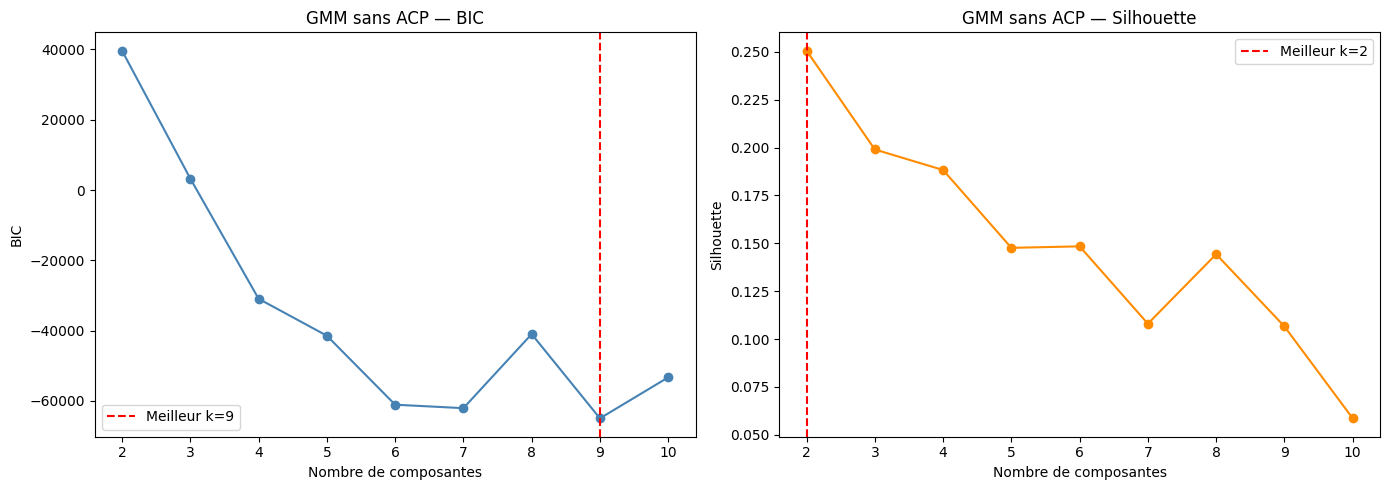

In [4]:
#PARTIE 1 — GMM SANS ACP
# ============================================
bic_sans_acp = []
silhouettes_sans_acp = []
K = range(2, 11)

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(df_scaled)
    labels = gmm.predict(df_scaled)
    bic_sans_acp.append(gmm.bic(df_scaled))
    silhouettes_sans_acp.append(silhouette_score(df_scaled, labels))

k_bic = list(K)[np.argmin(bic_sans_acp)]
k_sil = list(K)[np.argmax(silhouettes_sans_acp)]

print("===== GMM SANS ACP =====")
print(f"K optimal (BIC)        : {k_bic}")
print(f"K optimal (silhouette) : {k_sil}")
print(f"Silhouette scores      : {[round(s, 3) for s in silhouettes_sans_acp]}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, bic_sans_acp, marker='o', color='steelblue')
axes[0].axvline(x=k_bic, color='red', linestyle='--', label=f'Meilleur k={k_bic}')
axes[0].set_title("GMM sans ACP — BIC")
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("BIC")
axes[0].legend()

axes[1].plot(K, silhouettes_sans_acp, marker='o', color='darkorange')
axes[1].axvline(x=k_sil, color='red', linestyle='--', label=f'Meilleur k={k_sil}')
axes[1].set_title("GMM sans ACP — Silhouette")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Silhouette")
axes[1].legend()
plt.tight_layout()
plt.show()


In [5]:
# Modèle final sans ACP
k_final = k_sil
gmm_sans_acp = GaussianMixture(n_components=k_final, random_state=42)
gmm_sans_acp.fit(df_scaled)
df['Cluster_GMM'] = gmm_sans_acp.predict(df_scaled)
print(f"\nK retenu : {k_final}")
print(f"Répartition :\n{df['Cluster_GMM'].value_counts()}")


K retenu : 2
Répartition :
Cluster_GMM
0    1554
1     662
Name: count, dtype: int64


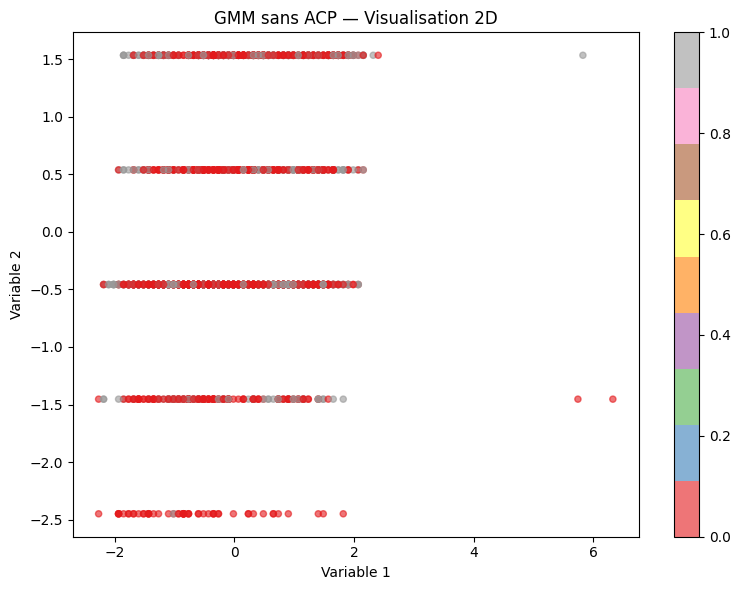

In [6]:
# Visualisation 2D sans ACP
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_scaled[:, 0], df_scaled[:, 1],
                      c=df['Cluster_GMM'], cmap='Set1', alpha=0.6, s=20)
plt.colorbar(scatter)
plt.title("GMM sans ACP — Visualisation 2D")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.tight_layout()
plt.show()


===== GMM AVEC ACP =====
K optimal (BIC)        : 8
K optimal (silhouette) : 2
Silhouette scores      : [0.328, 0.196, 0.184, 0.172, 0.163, 0.153, 0.128, 0.088, 0.093]


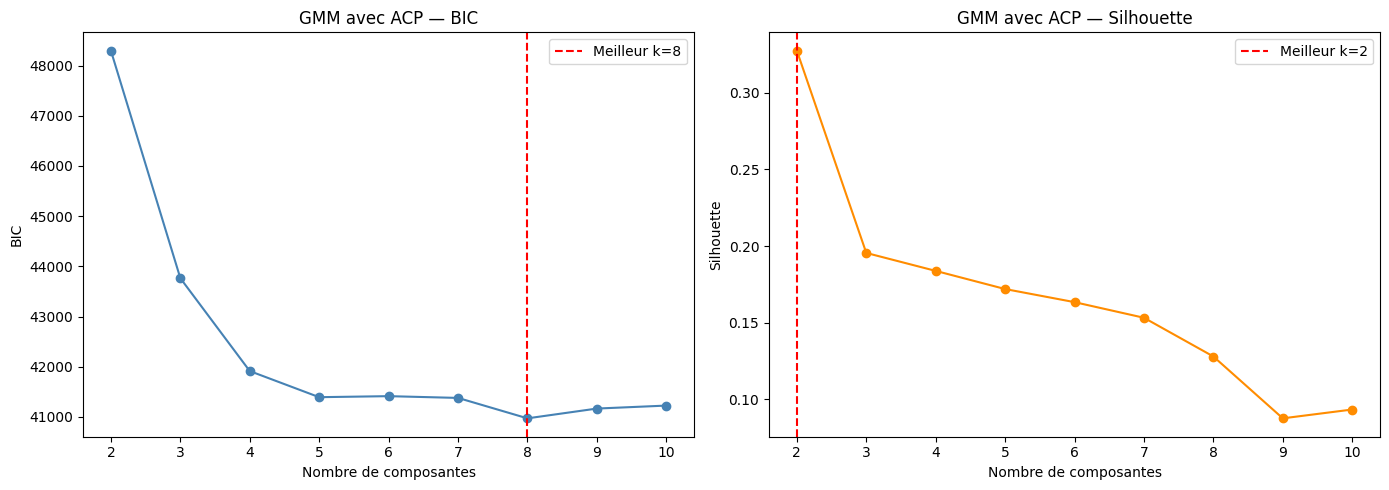

In [7]:
#PARTIE 2 — GMM AVEC ACP
# ============================================
bic_avec_acp = []
silhouettes_avec_acp = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(df_pca)
    labels = gmm.predict(df_pca)
    bic_avec_acp.append(gmm.bic(df_pca))
    silhouettes_avec_acp.append(silhouette_score(df_pca, labels))

k_bic_pca = list(K)[np.argmin(bic_avec_acp)]
k_sil_pca = list(K)[np.argmax(silhouettes_avec_acp)]

print("\n===== GMM AVEC ACP =====")
print(f"K optimal (BIC)        : {k_bic_pca}")
print(f"K optimal (silhouette) : {k_sil_pca}")
print(f"Silhouette scores      : {[round(s, 3) for s in silhouettes_avec_acp]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, bic_avec_acp, marker='o', color='steelblue')
axes[0].axvline(x=k_bic_pca, color='red', linestyle='--', label=f'Meilleur k={k_bic_pca}')
axes[0].set_title("GMM avec ACP — BIC")
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("BIC")
axes[0].legend()

axes[1].plot(K, silhouettes_avec_acp, marker='o', color='darkorange')
axes[1].axvline(x=k_sil_pca, color='red', linestyle='--', label=f'Meilleur k={k_sil_pca}')
axes[1].set_title("GMM avec ACP — Silhouette")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Silhouette")
axes[1].legend()
plt.tight_layout()
plt.show()



K retenu avec ACP : 2
Répartition :
Cluster_GMM_ACP
0    1258
1     958
Name: count, dtype: int64


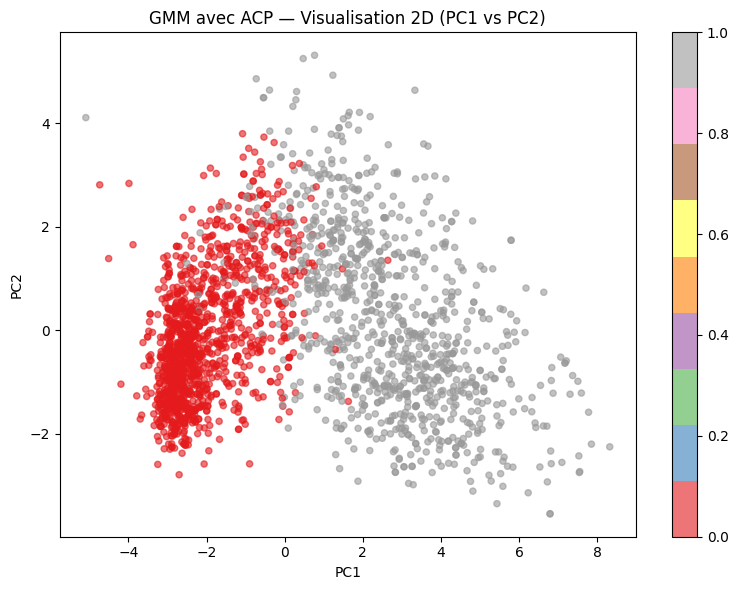

In [8]:
# Modèle final avec ACP
k_final_pca = k_sil_pca
gmm_avec_acp = GaussianMixture(n_components=k_final_pca, random_state=42)
gmm_avec_acp.fit(df_pca)
df['Cluster_GMM_ACP'] = gmm_avec_acp.predict(df_pca)
print(f"\nK retenu avec ACP : {k_final_pca}")
print(f"Répartition :\n{df['Cluster_GMM_ACP'].value_counts()}")

# Visualisation 2D avec ACP
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1],
                      c=df['Cluster_GMM_ACP'], cmap='Set1', alpha=0.6, s=20)
plt.colorbar(scatter)
plt.title("GMM avec ACP — Visualisation 2D (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [9]:
# COMPARAISON FINALE
# ============================================
print("\n===== COMPARAISON FINALE GMM =====")
print(f"Sans ACP — k={k_final},     silhouette={max(silhouettes_sans_acp):.3f}")
print(f"Avec ACP — k={k_final_pca}, silhouette={max(silhouettes_avec_acp):.3f}")


===== COMPARAISON FINALE GMM =====
Sans ACP — k=2,     silhouette=0.251
Avec ACP — k=2, silhouette=0.328
